# Assignment 5 — Diabetes với CNN 1D

**Môn:** Phân tích và Phát triển Hệ thống Thông minh

Notebook này giữ cùng cấu trúc với hai notebook ảnh:

1. Giới thiệu dataset  
2. Load + khảo sát  
3. Tiền xử lý  
4. CNN 1D cơ bản → train → đánh giá  
5. LeNet-like 1D → train → đánh giá  
6. VGG-like 1D → train → đánh giá  
7. ResNet-like 1D → train → đánh giá  
8. So sánh  
9. Kết luận

> **Lưu ý quan trọng:** Diabetes là dữ liệu bảng, không phải ảnh. Để thực nghiệm CNN theo yêu cầu bài, mỗi hàng được biểu diễn thành chuỗi đặc trưng `(features, 1)` và dùng `Conv1D`. Các phiên bản LeNet/VGG/ResNet ở đây là **bản thích nghi 1D**, không phải kiến trúc ảnh nguyên bản.

## 1. Bài toán

File dùng:

`data/diabetes/diabetes.csv`

Mục tiêu: phân loại nhị phân:
- `0`: không diabetes
- `1`: diabetes

Vì dữ liệu có thể lệch lớp nên ngoài Accuracy cần xem thêm **Precision, Recall và F1-score**.

In [1]:
from pathlib import Path
import time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "notebooks" else CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"
FIGURE_DIR = PROJECT_DIR / "outputs" / "figures"
RESULT_DIR = PROJECT_DIR / "outputs" / "results"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

PROJECT_DIR: D:\Assignment5\Assignment5_CNN_Project
TensorFlow: 2.21.0
GPU: []


## 2. Load và khảo sát Diabetes

In [2]:
DIABETES_PATH = DATA_DIR / "diabetes" / "diabetes.csv"
assert DIABETES_PATH.exists(), f"Không tìm thấy {DIABETES_PATH}"

df = pd.read_csv(DIABETES_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())
print("Missing:", int(df.isna().sum().sum()))

Shape: (253680, 22)
Columns: ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Missing: 0


In [3]:
target_candidates = [
    "Diabetes_binary", "Diabetes_012", "Outcome",
    "diabetes", "target", "label"
]

target_col = next((c for c in target_candidates if c in df.columns), None)

if target_col is None:
    raise ValueError("Không tìm được cột target. Hãy kiểm tra df.columns.")

print("Target:", target_col)
print(df[target_col].value_counts().sort_index())
print(df[target_col].value_counts(normalize=True).sort_index())

Target: Diabetes_binary
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64
Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64


## 3. Tiền xử lý dữ liệu

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

X_df = df.drop(columns=[target_col]).copy()
X_df = X_df.apply(pd.to_numeric, errors="coerce")
X_df = X_df.fillna(X_df.median(numeric_only=True))

y_raw = df[target_col].to_numpy()
unique_targets = np.sort(pd.Series(y_raw).dropna().unique())

if len(unique_targets) != 2:
    raise ValueError(
        "Notebook này cấu hình cho Diabetes nhị phân. "
        "Hãy dùng file diabetes_binary_health_indicators_BRFSS2015.csv "
        "và đổi tên thành diabetes.csv."
    )

mapping = {unique_targets[0]: 0, unique_targets[1]: 1}
y = np.vectorize(mapping.get)(y_raw).astype(np.int64)
X = X_df.to_numpy(dtype=np.float32)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, random_state=SEED, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Conv1D cần (samples, steps, channels)
X_train = X_train[..., np.newaxis].astype(np.float32)
X_val = X_val[..., np.newaxis].astype(np.float32)
X_test = X_test[..., np.newaxis].astype(np.float32)

classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
CLASS_WEIGHT = {int(c): float(w) for c, w in zip(classes, weights)}

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)
print("Class weight:", CLASS_WEIGHT)

Train: (162355, 21, 1)
Val  : (40589, 21, 1)
Test : (50736, 21, 1)
Class weight: {0: 0.5809472350840531, 1: 3.5884316152418}


In [5]:
def plot_history(history, dataset_name, model_name):
    h = history.history

    plt.figure(figsize=(7, 4))
    plt.plot(h["accuracy"], label="Train")
    plt.plot(h["val_accuracy"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{dataset_name} - {model_name} - Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{dataset_name}_{model_name}_accuracy.png", dpi=150)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(h["loss"], label="Train")
    plt.plot(h["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{dataset_name} - {model_name} - Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{dataset_name}_{model_name}_loss.png", dpi=150)
    plt.show()


def evaluate_binary(model, X, y_true, dataset_name, model_name):
    probs = model.predict(X, verbose=0).reshape(-1)
    y_pred = (probs >= 0.5).astype(int)

    row = {
        "dataset": dataset_name,
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "params": int(model.count_params()),
    }

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay(
        cm, display_labels=["No diabetes", "Diabetes"]
    ).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{dataset_name} - {model_name}")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{dataset_name}_{model_name}_confusion_matrix.png", dpi=150)
    plt.show()

    return row

## 4. CNN 1D cơ bản

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 21, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 10, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 10, 64)              │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,561 (41.25 KB)

 Trainable params: 10,561 (41.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.6992 - loss: 0.5575 - val_accuracy: 0.7042 - val_loss: 0.5390
Epoch 2/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7077 - loss: 0.5212 - val_accuracy: 0.7078 - val_loss: 0.5309
Epoch 3/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7086 - loss: 0.5155 - val_accuracy: 0.7145 - val_loss: 0.5153
Epoch 4/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7096 - loss: 0.5130 - val_accuracy: 0.7200 - val_loss: 0.5075
Epoch 5/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7094 - loss: 0.5116 - val_accuracy: 0.7183 - val_loss: 0.5085
Epoch 6/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7092 - loss: 0.5105 - val_accuracy: 0.7165 - val_loss: 0.5098


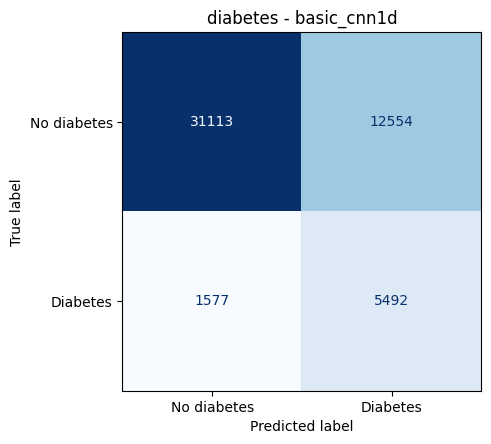

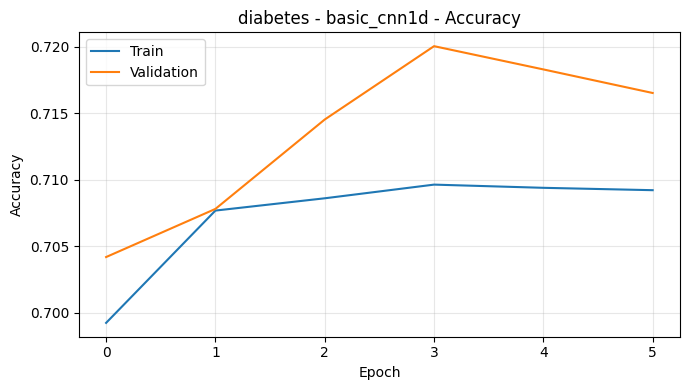

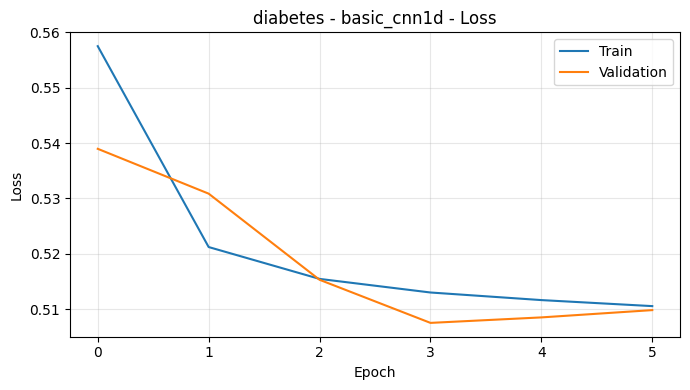

In [6]:
def build_basic_diabetes():
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1], 1)),
        layers.Conv1D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, padding="same", activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

results = []
EPOCHS = 8
BATCH_SIZE = 256

model = build_basic_diabetes()
model.summary()

start = time.perf_counter()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHT,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)
seconds = time.perf_counter() - start

test_loss, _ = model.evaluate(X_test, y_test, verbose=0)
row = evaluate_binary(model, X_test, y_test, "diabetes", "basic_cnn1d")
row["loss"] = float(test_loss)
row["train_seconds"] = seconds
results.append(row)

plot_history(history, "diabetes", "basic_cnn1d")
model.save(MODEL_DIR / "diabetes_basic_cnn1d.keras")

## 5. Mô hình cải tiến 1 — LeNet-like 1D

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 21, 6)               │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling1d (AveragePooling1D) │ (None, 10, 6)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 10, 16)              │             496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling1d_1                  │ (None, 5, 16)               │               0 │
│ (AveragePooling1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 80)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 120)                 │           9,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              85 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,501 (80.08 KB)

 Trainable params: 20,501 (80.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7249 - loss: 0.5203 - val_accuracy: 0.7196 - val_loss: 0.5392
Epoch 2/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7237 - loss: 0.5125 - val_accuracy: 0.7071 - val_loss: 0.5438
Epoch 3/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7142 - loss: 0.5090 - val_accuracy: 0.7023 - val_loss: 0.5393


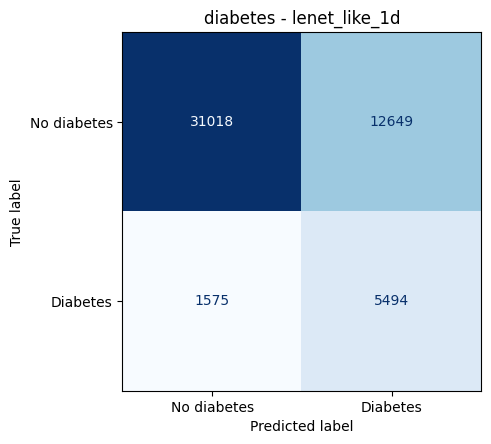

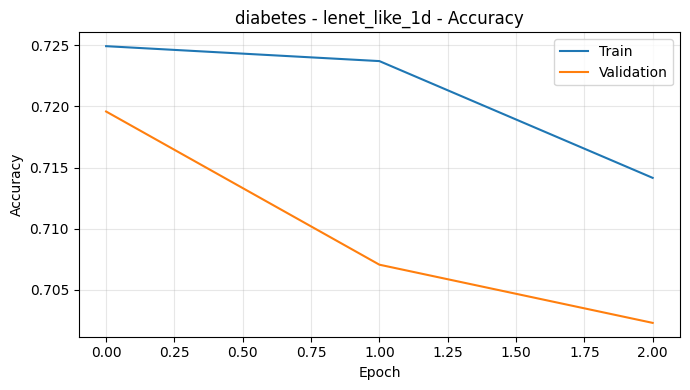

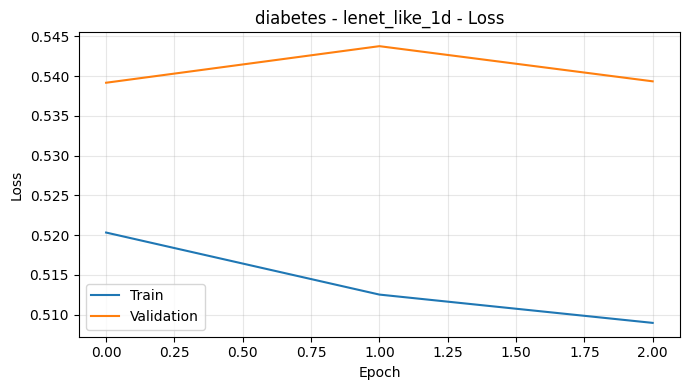

In [7]:
def build_lenet1d_diabetes():
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1], 1)),
        layers.Conv1D(6, 5, padding="same", activation="tanh"),
        layers.AveragePooling1D(2),
        layers.Conv1D(16, 5, padding="same", activation="tanh"),
        layers.AveragePooling1D(2),
        layers.Flatten(),
        layers.Dense(120, activation="tanh"),
        layers.Dense(84, activation="tanh"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_lenet1d_diabetes()
model.summary()

start = time.perf_counter()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHT,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)
seconds = time.perf_counter() - start

test_loss, _ = model.evaluate(X_test, y_test, verbose=0)
row = evaluate_binary(model, X_test, y_test, "diabetes", "lenet_like_1d")
row["loss"] = float(test_loss)
row["train_seconds"] = seconds
results.append(row)

plot_history(history, "diabetes", "lenet_like_1d")
model.save(MODEL_DIR / "diabetes_lenet_like_1d.keras")

## 6. Mô hình cải tiến 2 — VGG-like 1D

Model: "vgg_like_1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 21, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 21, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 21, 32)              │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 10, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_6 (Conv1D)                    │ (None, 10, 64)              │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ (None, 10, 64)              │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_8 (Conv1D)                    │ (None, 5, 128)              │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_1           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 54,817 (214.13 KB)

 Trainable params: 54,817 (214.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.6918 - loss: 0.5393 - val_accuracy: 0.7267 - val_loss: 0.4988
Epoch 2/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.7076 - loss: 0.5120 - val_accuracy: 0.6816 - val_loss: 0.5666
Epoch 3/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7097 - loss: 0.5089 - val_accuracy: 0.7015 - val_loss: 0.5381


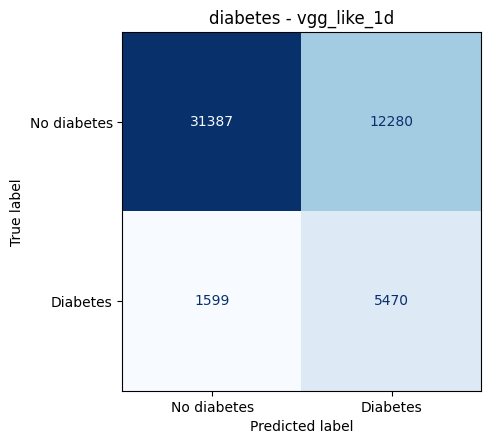

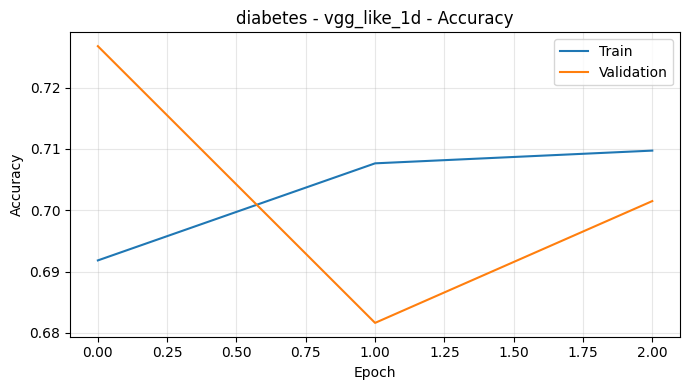

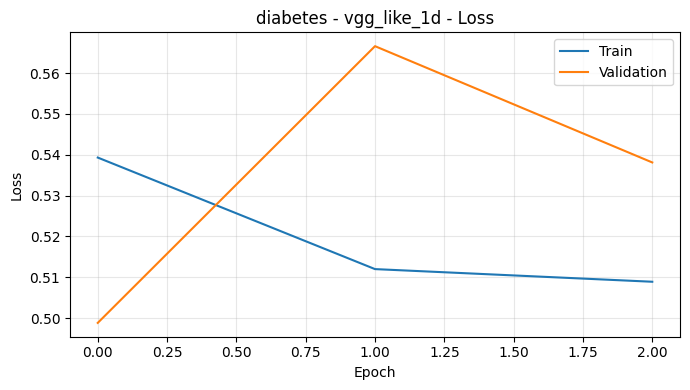

In [8]:
def build_vgg1d_diabetes():
    inputs = keras.Input(shape=(X_train.shape[1], 1))

    x = layers.Conv1D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.Conv1D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv1D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs, name="vgg_like_1d")

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_vgg1d_diabetes()
model.summary()

start = time.perf_counter()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHT,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)
seconds = time.perf_counter() - start

test_loss, _ = model.evaluate(X_test, y_test, verbose=0)
row = evaluate_binary(model, X_test, y_test, "diabetes", "vgg_like_1d")
row["loss"] = float(test_loss)
row["train_seconds"] = seconds
results.append(row)

plot_history(history, "diabetes", "vgg_like_1d")
model.save(MODEL_DIR / "diabetes_vgg_like_1d.keras")

## 7. Mô hình cải tiến 3 — ResNet-like 1D

Model: "resnet_like_1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 21, 1)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_9 (Conv1D)             │ (None, 21, 32)            │              96 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 21, 32)            │             128 │ conv1d_9[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu (ReLU)                  │ (None, 21, 32)            │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_10 (Conv1D)            │ (None, 21, 32)            │           3,072 │ re_lu[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 21, 32)            │             128 │ conv1d_10[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_1 (ReLU)                │ (None, 21, 32)            │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_11 (Conv1D)            │ (None, 21, 32)            │           3,072 │ re_lu_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 21, 32)            │             128 │ conv1d_11[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 21, 32)            │               0 │ batch_normalization_2[0][… │
│                               │                           │                 │ re_lu[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_2 (ReLU)                │ (None, 21, 32)            │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_12 (Conv1D)            │ (None, 11, 64)            │           6,144 │ re_lu_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 11, 64)            │             256 │ conv1d_12[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_3 (ReLU)                │ (None, 11, 64)            │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_13 (Conv1D)            │ (None, 11, 64)            │          12,28

 Total params: 53,025 (207.13 KB)

 Trainable params: 52,193 (203.88 KB)

 Non-trainable params: 832 (3.25 KB)

Epoch 1/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 48s 44ms/step - accuracy: 0.7177 - loss: 0.5178 - val_accuracy: 0.6792 - val_loss: 0.6111
Epoch 2/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.7211 - loss: 0.5082 - val_accuracy: 0.7125 - val_loss: 0.5459
Epoch 3/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.7215 - loss: 0.5054 - val_accuracy: 0.7137 - val_loss: 0.5403
Epoch 4/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.7217 - loss: 0.5036 - val_accuracy: 0.7261 - val_loss: 0.5175
Epoch 5/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 33s 51ms/step - accuracy: 0.7228 - loss: 0.5021 - val_accuracy: 0.7262 - val_loss: 0.5162
Epoch 6/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.7231 - loss: 0.5010 - val_accuracy: 0.7360 - val_loss: 0.4981
Epoch 7/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 43s 67ms/step - accuracy: 0.7238 - loss: 0.4998 - val_accuracy: 0.7313 - val_loss: 0.5078
Epoch 8/8
635/635 ━━━━━━━━━━━━━━━━━━━━ 47s 74ms/step - accuracy: 0.7241 - loss: 0.4988 - val_accu

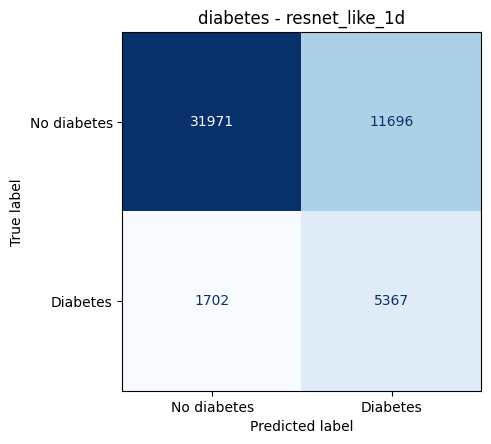

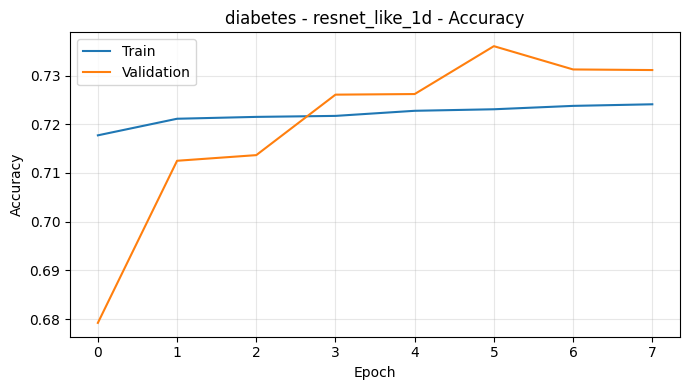

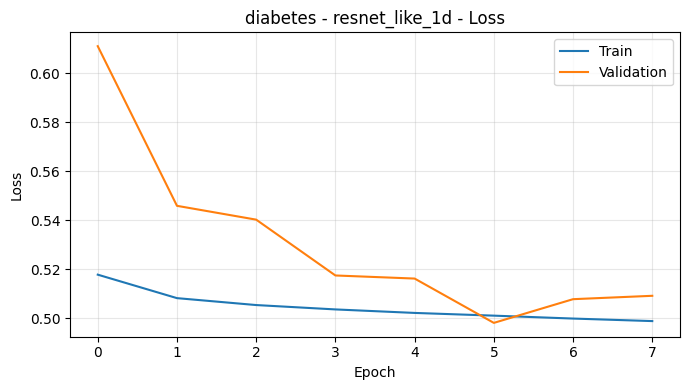

In [9]:
def residual_block_1d(x, filters, downsample=False):
    stride = 2 if downsample else 1
    shortcut = x

    x = layers.Conv1D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv1D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    return layers.ReLU()(x)

def build_resnet1d_diabetes():
    inputs = keras.Input(shape=(X_train.shape[1], 1))

    x = layers.Conv1D(32, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block_1d(x, 32)
    x = residual_block_1d(x, 64, downsample=True)
    x = residual_block_1d(x, 64)

    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="resnet_like_1d")
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_resnet1d_diabetes()
model.summary()

start = time.perf_counter()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHT,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)
seconds = time.perf_counter() - start

test_loss, _ = model.evaluate(X_test, y_test, verbose=0)
row = evaluate_binary(model, X_test, y_test, "diabetes", "resnet_like_1d")
row["loss"] = float(test_loss)
row["train_seconds"] = seconds
results.append(row)

plot_history(history, "diabetes", "resnet_like_1d")
model.save(MODEL_DIR / "diabetes_resnet_like_1d.keras")

## 8. So sánh kết quả

,dataset,model,accuracy,precision,recall,f1,params,loss,train_seconds
3,diabetes,resnet_like_1d,0.735927,0.314540,0.759230,0.444804,53025,0.501339,282.166468
2,diabetes,vgg_like_1d,0.726447,0.308169,0.773801,0.440791,54817,0.500335,50.177366
0,diabetes,basic_cnn1d,0.721480,0.304333,0.776913,0.437348,10561,0.509178,51.219853
1,diabetes,lenet_like_1d,0.719647,0.302817,0.777196,0.435824,20501,0.541327,15.739526


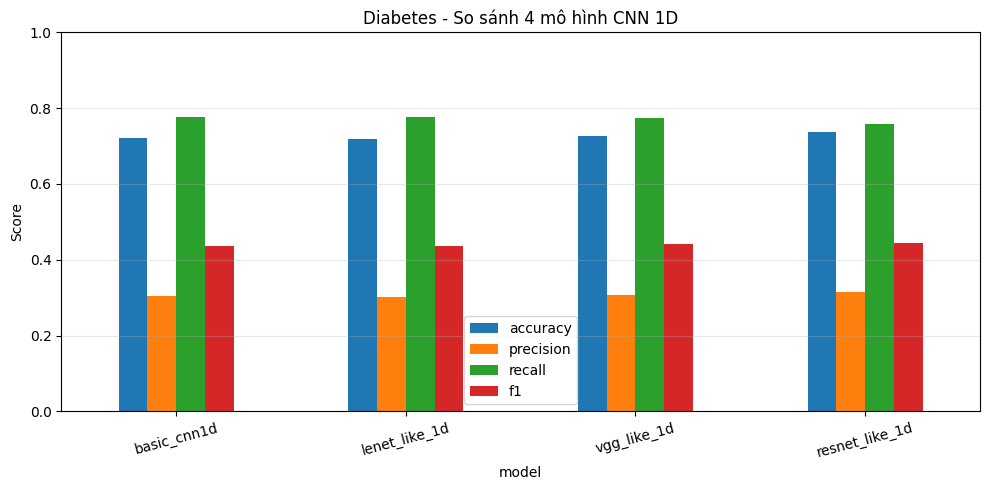

In [10]:
results_df = pd.DataFrame(results)
display(results_df.sort_values("f1", ascending=False))

results_df.to_csv(RESULT_DIR / "diabetes_results.csv", index=False)

ax = results_df.set_index("model")[["accuracy", "precision", "recall", "f1"]].plot(
    kind="bar", figsize=(10, 5)
)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Diabetes - So sánh 4 mô hình CNN 1D")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "diabetes_model_comparison.png", dpi=150)
plt.show()

## 9. Kết luận

Với Diabetes, **không nên chỉ nhìn Accuracy**. Hãy chú ý đặc biệt tới:
- Recall của lớp Diabetes
- F1-score
- Confusion matrix
- Mức độ lệch lớp

Đồng thời nêu rõ hạn chế: CNN 1D trên dữ liệu bảng là một thực nghiệm theo yêu cầu CNN; quan hệ giữa các feature không có cấu trúc không gian tự nhiên như pixel ảnh.